# W&B Sweep — DQN
Búsqueda de hiperparámetros para el agente DQN en el ambiente Simple (CSTR).
- Método: Random Search
- Proyecto W&B: `Tesis_DQN_ORCH`
- Arquitectura: Compleja (ORCH+CTRL)

## 1. Instalación e Imports

In [1]:
import os
import random
import numpy as np
import torch
import wandb
import sys
import pandas as pd
import matplotlib.pyplot as plt
import types

In [2]:
# Clonar desde Github:
!git clone https://github.com/valeriaeskenazi/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning.git
PROJECT_PATH = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4'
sys.path.append(PROJECT_PATH)

Cloning into 'Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning'...
remote: Enumerating objects: 1460, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 1460 (delta 8), reused 17 (delta 7), pack-reused 1440 (from 1)
Receiving objects: 100% (1460/1460), 32.47 MiB | 36.98 MiB/s, done.
Resolving deltas: 100% (872/872), done.


In [3]:
from Environment.Simulation_Env.Reactor_CSTR import CSTRSimulator
from Environment.PIDControlEnv_simple import PIDControlEnv_Simple
from Environment.PIDControlEnv_complex import PIDControlEnv_Complex
from Agente.DQN.train_DQN import DQNTrainer
from Agente.DQN.algorithm_DQN import DQNAgent
from Aux.Plots import SimplePlotter, print_summary

print('Imports completados')
print(f'PyTorch: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')

Imports completados
PyTorch: 2.10.0+cu128
Device: CUDA


In [4]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Sun Mar  8 12:39:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       3MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Login W&B

In [5]:
!pip install wandb --quiet

In [6]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ve326684 (ve326684-universidad-ort-uruguay) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## 3. Configuración del Sweep

In [7]:

WANDB_ENTITY  = 've326684-universidad-ort-uruguay'
WANDB_PROJECT = 'Tesis_DQN_ORCH'
RUN_NAME      = 'orch_test4_15k'
CTRL_CHECKPOINT = '/content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best_Test2.pt'

N_EPISODES               = 15000
EVAL_FREQUENCY           = 100
LOG_FREQUENCY            = 100
SAVE_FREQUENCY           = 2000
EARLY_STOPPING_PATIENCE  = 50
EARLY_STOPPING_MIN_DELTA_PCT = 0.01
SEED                     = 42
DEVICE                   = 'cuda' if torch.cuda.is_available() else 'cpu'

MANIPULABLE_RANGES = [(300, 420), (90, 115)]

trainer_config = {
    'env_config': {
        'architecture'        : 'jerarquica',
        'env_type'            : 'simulation',
        'n_manipulable_vars'  : 2,
        'manipulable_ranges'  : MANIPULABLE_RANGES,
        'n_target_vars'       : 1,
        'target_ranges'       : [(0.0, 1.0)],
        'target_setpoints'    : [0.4],
        'target_working_ranges': [(0.0, 2.0)],
        'dt_usuario'          : 1.0,
        'max_steps'           : 100,
        'max_time_detector'   : 30,
        'reward_dead_band'    : 0.02,
        'delta_percent_ctrl'  : 0.3,
        'delta_percent_orch'  : 0.05,
        'reward_weights'      : {'error': 1.0, 'tiempo': 0.3, 'overshoot': 0.2, 'energy': 0.1},
        'pid_limits'          : [(0.01, 5.0), (0.001, 1.0), (0.0001, 1.0)],
        'agent_orchestrator_config': {'agent_type': 'discrete'},
        'env_type_config'     : {'dt': 1.0, 'control_limits': (MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1])},
        'stability_config'    : {
            'error_increase_tolerance': 2.0,
            'max_sign_changes_ratio'  : 0.2,
            'max_abrupt_change_ratio' : 0.03,
            'abrupt_change_threshold' : 0.3,
        },
    },

    'ctrl_checkpoint_path': CTRL_CHECKPOINT,
    'agent_ctrl_config': {
        'state_dim'  : 10,
        'action_dim' : 7,
        'n_vars'     : 2,
        'action_type': 'discrete',
        'hidden_dims': (128, 64),
        'device'     : DEVICE,
    },

    'agent_orch_config': {
        'state_dim'         : 5,
        'action_dim'        : 3,
        'n_vars'            : 2,
        'hidden_dims'       : (128, 64),
        'lr'                : 1e-4,
        'gamma'             : 0.99,
        'epsilon_start'     : 1.0,
        'epsilon_min'       : 0.01,
        'epsilon_decay'     : 0.9995,
        'batch_size'        : 32,
        'target_update_freq': 50,
        'buffer_type'       : 'priority',
        'buffer_size'       : 10000,
        'device'            : DEVICE,
        'seed'              : SEED,
    },

    'n_episodes'                 : N_EPISODES,
    'eval_frequency'             : EVAL_FREQUENCY,
    'log_frequency'              : LOG_FREQUENCY,
    'save_frequency'             : SAVE_FREQUENCY,
    'checkpoint_dir'             : f'checkpoints/{RUN_NAME}',
    'early_stopping_patience'    : EARLY_STOPPING_PATIENCE,
    'early_stopping_min_delta_pct': EARLY_STOPPING_MIN_DELTA_PCT,
    'use_wandb': True,
}

# Reproducibilidad
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# Init W&B
wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = RUN_NAME,
    tags    = ['post-fix', 'orch', '15k', 'produccion'],
    config  = trainer_config,
)

# Entrenar
cstr = CSTRSimulator(dt=1.0, control_limits=(MANIPULABLE_RANGES[0], MANIPULABLE_RANGES[1]))
trainer = DQNTrainer(trainer_config)
trainer.env.proceso.connect_external_process(cstr)
trainer.train()

# Guardar pesos en W&B
import os
checkpoint_path = f'checkpoints/{RUN_NAME}'
if os.path.exists(checkpoint_path):
    artifact = wandb.Artifact(
        name        = f'model_{RUN_NAME}',
        type        = 'model',
        description = 'Pesos ORCH post-fix, 15k episodios'
    )
    artifact.add_dir(checkpoint_path)
    wandb.log_artifact(artifact)
    print('✓ Pesos guardados en W&B')

# Métricas finales
wandb.log({
    'final_eval_reward'      : trainer.best_reward,
    'total_episodes'         : len(trainer.episode_rewards),
    'final_epsilon'          : trainer.epsilons[-1] if trainer.epsilons else 0,
    'final_reward_mean10'    : np.mean(trainer.episode_rewards[-10:]),
    'final_energy_mean10'    : np.mean(trainer.episode_energies[-10:]),
    'final_overshoot_mean10' : np.mean(trainer.episode_max_overshoots[-10:]),
})

run_name = wandb.run.name
wandb.finish()
print(f'Run completado: {run_name}')

Cargando agente CTRL pre-entrenado desde: /content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best_Test2.pt

Episodio 0/15000
  Reward: -2.40
  Length: 100
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 53.9089
  ORCH Epsilon: 0.9661

Episodio 100/15000
  Reward: -2.35
  Length: 3
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 3.2787
  ORCH Epsilon: 0.0100
Evaluación: Reward promedio = -4.10
Agente guardado en: checkpoints/orch_test4_15k/agent_ctrl_best.pt
Agente guardado en: checkpoints/orch_test4_15k/agent_orch_best.pt
Checkpoint guardado: best

Episodio 200/15000
  Reward: -12.44
  Length: 100
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 14.3606
  ORCH Epsilon: 0.0100
Evaluación: Reward promedio = -5.74
  Sin mejora: 1/50

Episodio 300/15000
  Reward: -1.95
  Length: 100
  CTRL Loss: 0.0000
  CTRL Epsilon: 0.0000
  ORCH Loss: 20.5949
  ORCH Epsilon: 0.0100
Evaluación: Reward promedio = -2.00

wandb: Adding directory to artifact (checkpoints/orch_test4_15k)... Done. 0.0s


Evaluación: Reward promedio = -0.41
  Sin mejora: 50/50
Early stopping en episodio 9800
✓ Pesos guardados en W&B


energy,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epsilon,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval_reward,▄▃▆▇▇██▇▆█▇██▇▆▇▇█▃███▄▄█▃▆▇█▃▅▇▇██▁▆▇▆█
final_energy_mean10,▁
final_epsilon,▁
final_eval_reward,▁
final_overshoot_mean10,▁
final_reward_mean10,▁
loss,▂▄▅▅█▂▂▂▁▁▂▂▃▃▁▂▂▂▁▁▂▂▂▁▁▂▁▁▁▁▂▂▂▁▁▁▁▁▁▁
overshoot,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Run completado: orch_test4_15k


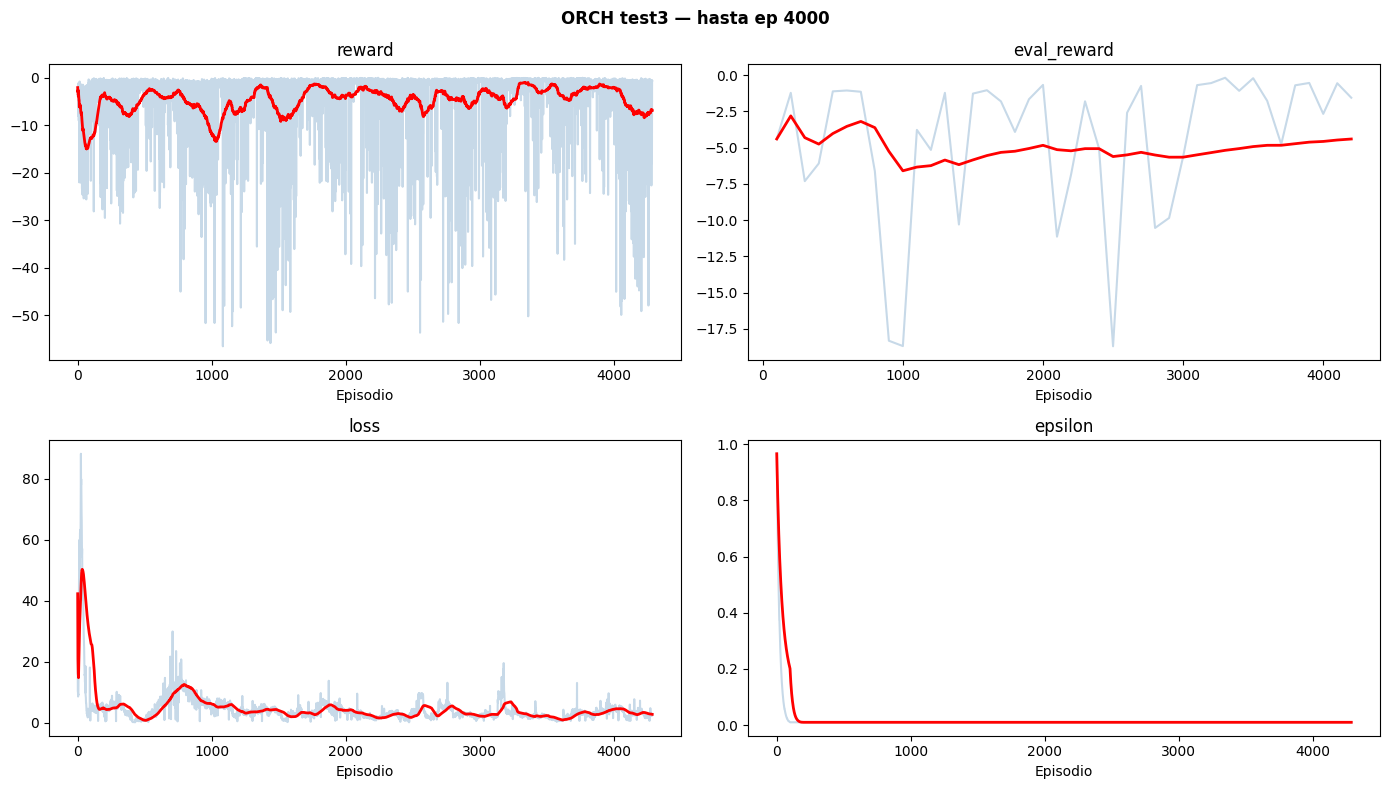

In [13]:
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH/4nefxi6i')
hist = list(r.scan_history())
df = pd.DataFrame(hist)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metricas = ['reward', 'eval_reward', 'loss', 'epsilon']

for ax, col in zip(axes.flat, metricas):
    if col in df.columns:
        d = df[['_step', col]].dropna()
        ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
        ax.plot(d['_step'], d[col].rolling(100, min_periods=1).mean(), color='red', lw=2)
        ax.set_title(col)
        ax.set_xlabel('Episodio')

plt.suptitle('ORCH test3 — hasta ep 4000', fontweight='bold')
plt.tight_layout()
plt.show()

La corrida crasheo, y consumio muchos recursos, y tampoco iba tan bien, vuelvo con otra.

## Nueva corrida de 15000 episodios

Analisis de resultados

In [9]:
api = wandb.Api()
r = api.run('ve326684-universidad-ort-uruguay/Tesis_DQN_ORCH/vhalznl6')
hist = list(r.scan_history())
print(len(hist), 'steps')
print(list(pd.DataFrame(hist).columns))

9801 steps
['loss', 'overshoot', '_runtime', 'reward', 'epsilon', 'energy', '_timestamp', '_step', 'eval_reward', 'final_overshoot_mean10', 'total_episodes', 'final_epsilon', 'final_reward_mean10', 'final_eval_reward', 'final_energy_mean10']


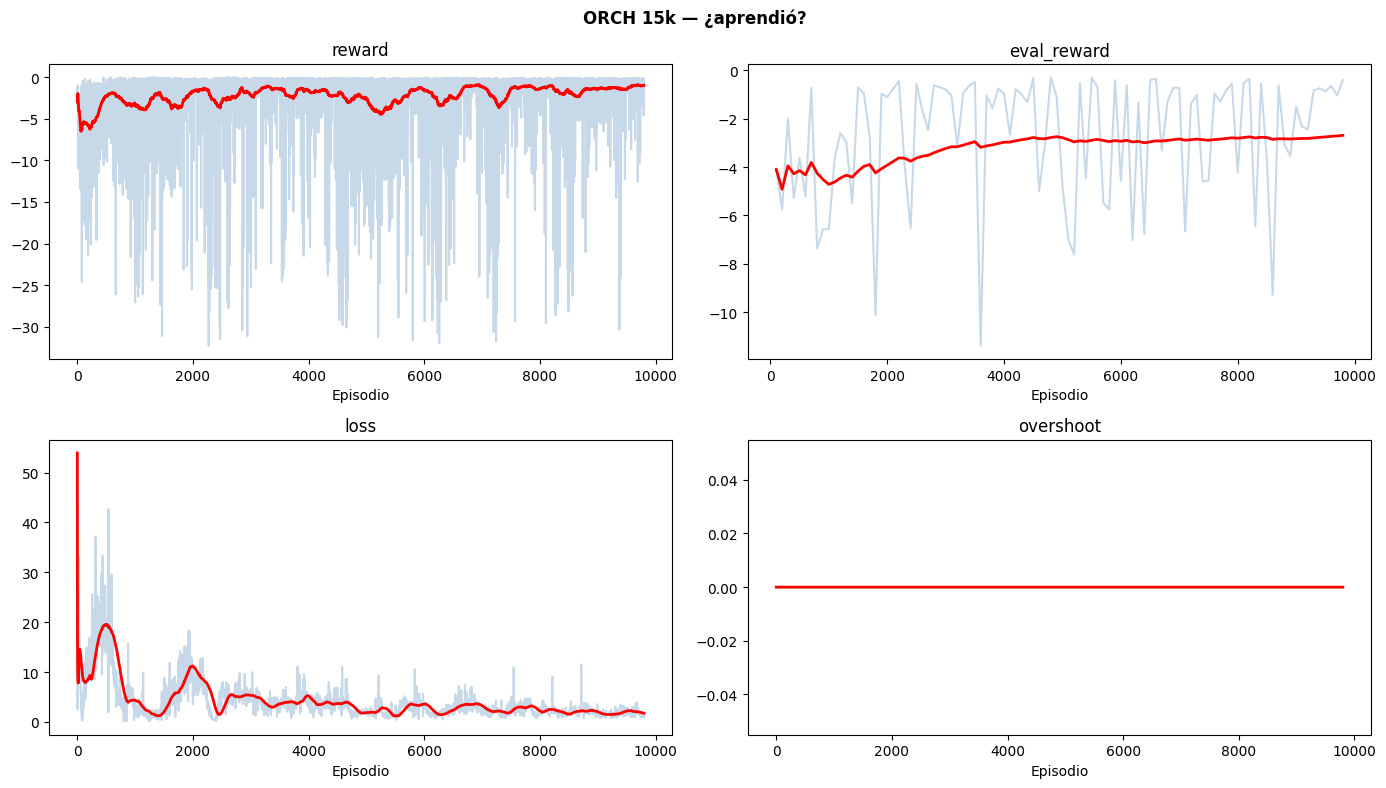

In [10]:
df_orch = pd.DataFrame(hist)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
metricas = ['reward', 'eval_reward', 'loss', 'overshoot']

for ax, col in zip(axes.flat, metricas):
    d = df_orch[['_step', col]].dropna()
    ax.plot(d['_step'], d[col], alpha=0.3, color='steelblue')
    ax.plot(d['_step'], d[col].rolling(200, min_periods=1).mean(), color='red', lw=2)
    ax.set_title(col)
    ax.set_xlabel('Episodio')

plt.suptitle('ORCH 15k — ¿aprendió?', fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
from Agente.DQN.algorithm_DQN import DQNAgent

In [12]:
# ── Cargar CTRL ────────────────────────────────────────────────────────────────
agent_ctrl = DQNAgent(state_dim=10, action_dim=7, n_vars=2, agent_role='ctrl',
                      hidden_dims=(128, 64), device='cpu', seed=42)
agent_ctrl.load('/content/checkpoints/orch_test4_15k/agent_ctrl_best.pt')
agent_ctrl.epsilon = 0.0

# ── Cargar ORCH ────────────────────────────────────────────────────────────────
agent_orch = DQNAgent(state_dim=5, action_dim=3, n_vars=2, agent_role='orch',
                      hidden_dims=(128, 64), device='cpu', seed=42)
agent_orch.load('/content/checkpoints/orch_test4_15k/agent_orch_best.pt')
agent_orch.epsilon = 0.0

print('Ambos agentes cargados')

Ambos agentes cargados


In [13]:
import matplotlib.pyplot as plt
import types
import numpy as np

def _run_episode_verbose(self, episode, training=False):
    obs = self.env.reset()[0]
    state_ctrl = obs['ctrl']
    state_orch = obs['orch']

    cstr = self.env.proceso.external_process

    cb_traj = [cstr.state[1]]
    T_traj  = [cstr.state[3]]
    V_traj  = [cstr.state[4]]

    done = False
    step = 0
    episode_reward = 0

    while not done and step < self.max_steps_per_episode:
        action_orch = self.agent_orch.select_action(state_orch, training=False)
        action_ctrl = self.agent_ctrl.select_action(state_ctrl, training=False)
        action = {'ctrl': action_ctrl, 'orch': action_orch}

        next_obs, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated

        cb_traj.append(cstr.state[1])
        T_traj.append(cstr.state[3])
        V_traj.append(cstr.state[4])

        state_ctrl = next_obs['ctrl']
        state_orch = next_obs['orch']
        episode_reward += reward
        step += 1

    # Graficar
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    steps = range(len(cb_traj))

    axes[0].plot(steps, cb_traj, color='green')
    axes[0].axhline(0.4, color='red', linestyle='--', label='Objetivo=0.4')
    axes[0].set_title('Cb (mol/m³)')
    axes[0].set_xlabel('Step')
    axes[0].legend()

    axes[1].plot(steps, T_traj, color='steelblue')
    axes[1].set_title('T (K)')
    axes[1].set_xlabel('Step')

    axes[2].plot(steps, V_traj, color='orange')
    axes[2].axhline(102, color='red', linestyle='--', label='V_ss=102')
    axes[2].set_title('V (m³)')
    axes[2].set_xlabel('Step')
    axes[2].legend()

    plt.suptitle(f'Evaluación ORCH+CTRL | Cb final={cb_traj[-1]:.4f} | Reward={episode_reward/step:.3f}',
                 fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f'Cb final: {cb_traj[-1]:.4f} | Error: {abs(cb_traj[-1]-0.4):.4f} | Reward: {episode_reward/step:.4f}')



Cargando agente CTRL pre-entrenado desde: /content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best_Test2.pt


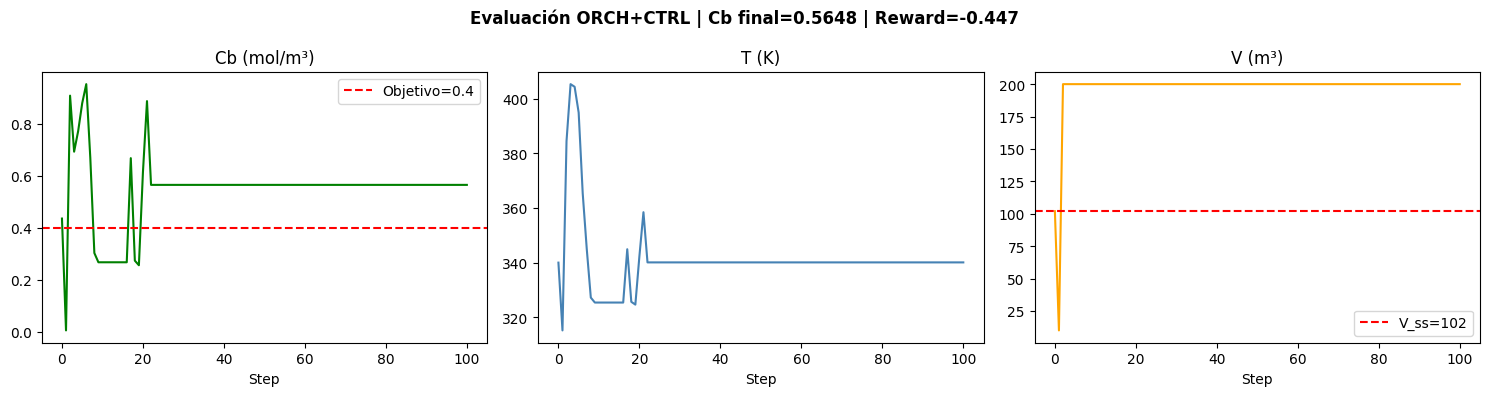

Cb final: 0.5648 | Error: 0.1648 | Reward: -0.4471


In [14]:

trainer_eval = DQNTrainer(trainer_config)
trainer_eval.env.proceso.connect_external_process(
    CSTRSimulator(dt=1.0, control_limits=((300, 420), (90, 115)))
)
trainer_eval.agent_ctrl.load('/content/checkpoints/orch_test4_15k/agent_ctrl_best.pt')
trainer_eval.agent_ctrl.epsilon = 0.0
trainer_eval.agent_orch.load('/content/checkpoints/orch_test4_15k/agent_orch_best.pt')
trainer_eval.agent_orch.epsilon = 0.0

# Evaluar y ver trayectorias
trainer_eval._run_episode_verbose = types.MethodType(_run_episode_verbose, trainer_eval)
trainer_eval._run_episode_verbose(episode=0, training=False)

Cargando agente CTRL pre-entrenado desde: /content/Control-PID-Adaptativo-Inteligente-mediante-Reinforcement-Learning/Version_4/Entrenamiento/CTRL/agent_ctrl_best_Test2.pt


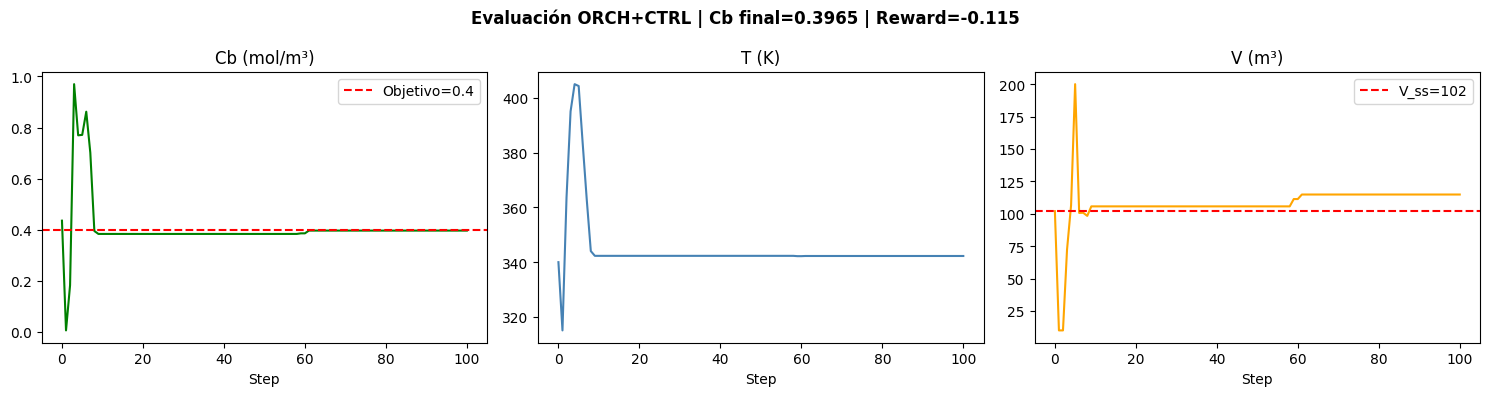

Cb final: 0.3965 | Error: 0.0035 | Reward: -0.1153


In [15]:

trainer_eval = DQNTrainer(trainer_config)
trainer_eval.env.proceso.connect_external_process(
    CSTRSimulator(dt=1.0, control_limits=((300, 420), (90, 115)))
)
trainer_eval.agent_ctrl.load('/content/checkpoints/orch_test4_15k/agent_ctrl_best.pt')
trainer_eval.agent_ctrl.epsilon = 0.0
trainer_eval.agent_orch.load('/content/checkpoints/orch_test4_15k/agent_orch_best.pt')
trainer_eval.agent_orch.epsilon = 0.0

# Evaluar y ver trayectorias
trainer_eval._run_episode_verbose = types.MethodType(_run_episode_verbose, trainer_eval)
trainer_eval._run_episode_verbose(episode=0, training=False)